## Multi-Model Application practice


In [1]:
# load libraries
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()

True

In [2]:
# call the API keys from environment variables
Groq_api_key = os.getenv("GROQ_API_KEY")
if Groq_api_key is None:
    raise ValueError("GROQ_API_KEY not found in environment variables")

Gemini_api_key = os.getenv("GEMINI_API_KEY")
if Gemini_api_key is None:
    raise ValueError("GEMINI_API_KEY not found in environment variables")

hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN") # name convention for Hugging Face API key is "HUGGINGFACEHUB_API_TOKEN"
if hf_token is None:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN not found in environment variables")

In [3]:
# step 1 - text to text 
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    max_tokens=1024,
    temperature=0,
    # reasoning_format={"reasoning_format": "parsed"}
    )

e:\Ai_engeering letecture_n_notes\assignment_multimodel_application\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langchain_core.messages import SystemMessage, HumanMessage

messages = [
    SystemMessage(content="You are a senior ML engineer. Be concise and technical."),
    HumanMessage(content="Explain what a transformer is in 3 lines.")
]

response = llm.invoke(messages)
print(response.content)

**Transformer Architecture**: A transformer is a type of neural network introduced in 2017, primarily used for natural language processing tasks. It relies on self-attention mechanisms to weigh the importance of different input elements relative to each other, allowing for parallelization and efficient processing of sequential data. The architecture consists of an encoder and a decoder, with the encoder generating continuous representations of input sequences.


In [5]:
# step 2 - image to text
#from langchain_groq import Groqvision
from langchain_google_genai import ChatGoogleGenerativeAI
import base64

# read the image and convert to base64

with open("test.jpg", "rb") as file:
    image_data = base64.b64encode(file.read()).decode("utf-8")

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    max_tokens=1024,
    temperature=1.0,
)

messages = [
    HumanMessage(
        content=[
            {"type": "image_url", "image_url":{"url": f"data:image/jpeg;base64,{image_data}"}},
            {"type": "text", "text": "describe the provided image in brief"}
        ]
    )]
response = llm.invoke(messages)
print(response)

content=[{'type': 'text', 'text': 'This is a stylized, digital illustration depicting a narrow Japanese alleyway. The image features a distinct artistic style with bold black outlines and a vibrant color palette dominated by shades of green, yellow, and teal. \n\nKey details include:\n* **The Street:** A narrow, paved pedestrian path that recedes into the background, lined with dense signage and storefronts.\n* **Signs and Lanterns:** Numerous vertical banners and lanterns with Japanese characters hang from the buildings.\n* **Mascot/Deity:** A prominent sign on the upper right features a cartoon illustration of a smiling, seated figure resembling a traditional mascot or deity (likely Billiken).\n* **Details:** Menu boards, shop entrances, and a partially visible bicycle on the right side add to the lively, cluttered atmosphere characteristic of a Japanese *yokocho* (alleyway).', 'extras': {'signature': 'EokZCoYZAQw51sc1qLDUH5QW/1Arzj3+lZGb02rA9SmM3BeT6zzGSBW2LLbC5P/FtXt4NezUjkEKXPIyRN

In [9]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="fal-ai",
    api_key=hf_token,
)
prompt = "Astronaut riding a horse"
# output is a PIL.Image object
image = client.text_to_image(
    prompt=prompt,
    model="black-forest-labs/FLUX.1-dev",
)
image.save("output.png")

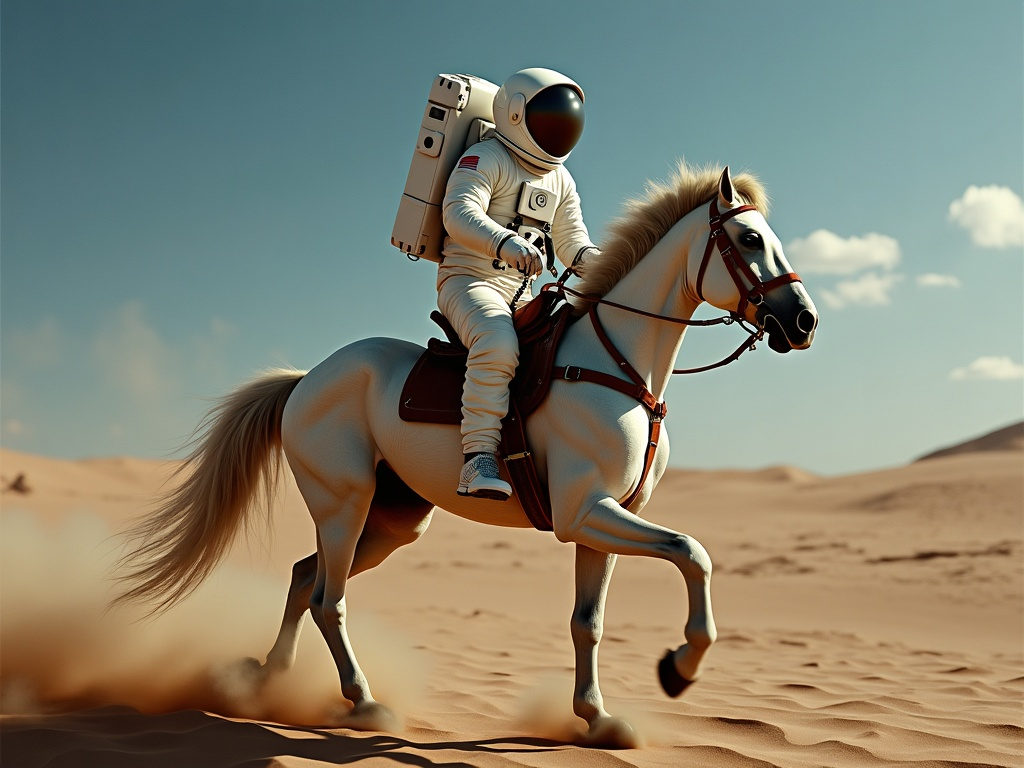

In [10]:
image

In [ ]:
# text to voice and image to voice
